In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn missingno -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno   # 결측 패턴 시각화 전용 라이브러리 (Part 3에서 사용)

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (운영체제별 분기)
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)


준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 (D+003 버전)
# - 어제 발견한 오염을 그대로 가져오되, 결측/이상치를 더 다양하게 심습니다.
# - 이 셀 하나로 오늘 쓸 데이터가 전부 준비됩니다 (이 노트북은 단독 실행 가능).
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers)
n_customers = 300
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
    "income": np.random.choice([2500, 3500, 4500, 6000, 8500], n_customers).astype(float),
})

# 오염 심기 — 나이 이상치
customers.loc[5, "age"] = 999            # 입력 실수로 보이는 이상치
customers.loc[10, "age"] = -3            # 음수 나이(불가능한 값)
customers.loc[15, "age"] = 120           # 매우 큰 값 (이상치 후보)

# 오염 심기 — 성별 결측 (관찰자가 응답을 안 받았을 가능성: MCAR에 가까움)
customers.loc[[20, 21, 22, 70, 120], "gender"] = np.nan

# 오염 심기 — 소득 결측 (고소득 고객일수록 응답 거절 → MNAR 신호)
high_income_mask = customers["income"] >= 6000
high_idx = customers[high_income_mask].sample(frac=0.4, random_state=1).index
customers.loc[high_idx, "income"] = np.nan

# 2) 상품(products)
categories = ["패션", "뷰티", "식품", "가전", "도서"]
n_products = 40
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(categories, n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders)
n_orders = 2000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "category": products.set_index("product_id").loc[order_product, "category"].values,
    "quantity": quantity,
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.5, 0.5]),
})

# 오염 심기 — 금액 결측 (일부 채널에서만 결측이 더 잦음 → MAR 신호)
app_mask = orders["channel"] == "app"
app_idx = orders[app_mask].sample(frac=0.04, random_state=2).index
web_idx = orders[~app_mask].sample(frac=0.01, random_state=3).index
orders.loc[app_idx.union(web_idx), "amount"] = np.nan

# 오염 심기 — 수량 이상치
orders.loc[7, "quantity"] = 100         # 비정상적으로 큰 주문 수량
orders.loc[1900, "quantity"] = 50       # 또 하나의 극단값
orders.loc[1500, "amount"] = 5_000_000  # 금액 자체의 극단값

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)
print("\n[빠르게 둘러보기]")
print("customers 결측:", customers.isnull().sum().sum(), "건")
print("orders 결측:", orders.isnull().sum().sum(), "건")

모두마켓 데이터 생성 완료
customers: (300, 6) | products: (40, 3) | orders: (2000, 7)

[빠르게 둘러보기]
customers 결측: 51 건
orders 결측: 51 건


In [3]:
# 첫인상 — 어제 했던 진단을 한 번 더, 빠르게
print("=== customers ===")
display(customers.head())
print("\n=== orders ===")
display(orders.head())

=== customers ===


,customer_id,age,gender,region,membership,income
0,C0001,39,M,경기,premium,6000.0
1,C0002,34,F,부산,basic,4500.0
2,C0003,41,F,서울,premium,8500.0
3,C0004,49,M,대구,vip,3500.0
4,C0005,33,M,서울,basic,2500.0



=== orders ===


,order_id,customer_id,product_id,category,quantity,amount,channel
0,O00001,C0111,P004,도서,1,29900.0,app
1,O00002,C0014,P029,패션,3,149700.0,app
2,O00003,C0231,P009,식품,2,39800.0,app
3,O00004,C0084,P027,도서,1,29900.0,web
4,O00005,C0130,P026,식품,2,19800.0,app


In [4]:
# 예제: .loc — 라벨(이름)로 가리키기
# customers의 인덱스는 0,1,2,... 정수이지만 '라벨'로 취급됩니다.

# 5번 라벨 행, 'age' 열 한 칸
print("customers.loc[5, 'age']  =", customers.loc[5, "age"])

# 0~3번 라벨 행, customer_id와 age 두 열만 (끝 포함!)
display(customers.loc[0:3, ["customer_id", "age"]])

customers.loc[5, 'age']  = 999


,customer_id,age
0,C0001,39
1,C0002,34
2,C0003,41
3,C0004,49


In [5]:
# 예제: 불리언 인덱싱 — 조건에 맞는 행 전부
# 조건(불리언 Series) 만들기
is_seoul = customers["region"] == "서울"
print("타입:", type(is_seoul).__name__, "/ True 개수:", is_seoul.sum())
print("앞 5개 미리보기:", is_seoul.head().tolist())

# 그 조건을 [ ]에 그대로 — 어제 본 패턴
seoul_customers = customers[is_seoul]
print("\n서울 고객 수:", len(seoul_customers))
display(seoul_customers.head(3))

타입: Series / True 개수: 62
앞 5개 미리보기: [False, False, True, False, True]

서울 고객 수: 62


,customer_id,age,gender,region,membership,income
2,C0003,41,F,서울,premium,8500.0
4,C0005,33,M,서울,basic,2500.0
5,C0006,999,F,서울,basic,NaN


In [6]:
# 예제: .loc + 불리언 — '조건 만족 행의 특정 열만' 가리키기 (오늘의 핵심 패턴)
# 30대 서울 고객의 멤버십만 꺼내기
mask = (customers["region"] == "서울") & (customers["age"].between(30, 39))
display(customers.loc[mask, ["customer_id", "age", "membership"]].head())

,customer_id,age,membership
4,C0005,33,basic
11,C0012,31,basic
21,C0022,33,basic
25,C0026,36,premium
41,C0042,37,basic


In [7]:
# 패턴 ①: 특정 조건 행의 한 열에 값 대입 — '서울'에 한해 region 값을 표준화
# 시연용 — 어제 표기 혼재로 본 ' 서울 '(앞뒤 공백)을 가상으로 만들었다가 정리
demo = customers.copy()
demo.loc[30, "region"] = " 서울 "
print("정리 전:", repr(demo.loc[30, "region"]))

# .loc로 그 한 칸을 지목해 값 대입
demo.loc[30, "region"] = demo.loc[30, "region"].strip()
print("정리 후:", repr(demo.loc[30, "region"]))

정리 전: ' 서울 '
정리 후: '서울'


In [8]:
# 1) 15번 라벨 행, age 열
print(customers.loc[15, "age"])

# 2) 패션 카테고리 + 수량 2 이상 주문의 order_id, amount 앞 5행
mask = (orders["category"] == "패션") & (orders["quantity"] >= 2)
display(orders.loc[mask, ["order_id", "amount"]].head())


120


,order_id,amount
1,O00002,149700.0
74,O00075,149700.0
85,O00086,19800.0
97,O00098,19800.0
108,O00109,19800.0


In [9]:
# 예제: isin과 between — 같은 결과를 두 방식으로
metro = ["서울", "경기", "인천"]

# 방법 A) 기본 |로 연결
mask_a = (customers["region"] == "서울") | (customers["region"] == "경기") | (customers["region"] == "인천")
print("방법 A 결과 수:", mask_a.sum())

# 방법 B) isin
mask_b = customers["region"].isin(metro)
print("방법 B 결과 수:", mask_b.sum())

# 두 결과가 완전히 같은지 검증
print("두 마스크가 완전히 동일?:", (mask_a == mask_b).all())

방법 A 결과 수: 176
방법 B 결과 수: 176
두 마스크가 완전히 동일?: True


In [10]:
# 예제: query — 문자열로 표현하는 필터
# 30대이면서 서울에 사는 프리미엄/VIP 고객
result = customers.query("age.between(30, 39) and region == '서울' and membership in ['premium', 'vip']")
print("해당 고객 수:", len(result))
display(result.head(3))

해당 고객 수: 4


,customer_id,age,gender,region,membership,income
25,C0026,36,M,서울,premium,2500.0
88,C0089,30,F,서울,premium,NaN
137,C0138,32,F,서울,premium,NaN


In [11]:
# 예제: ~ (NOT) — '서울 외 지역'
not_seoul = customers[~customers["region"].isin(["서울"])]
print("서울 외 지역 고객 수:", len(not_seoul))
print("지역 분포:")
print(not_seoul["region"].value_counts())

서울 외 지역 고객 수: 238
지역 분포:
region
부산    64
경기    60
대구    60
인천    54
Name: count, dtype: int64


In [12]:
# NaN과 비교는 항상 False 입니다 — 직관과 다름
sample = orders[["order_id", "amount"]].head(10).copy()
sample.loc[2, "amount"] = np.nan
display(sample)

print("\n== amount > 0 인 행 ==")
display(sample[sample["amount"] > 0])     # NaN 행은 제외됨 (조건이 False로 평가)

print("\n== amount <= 0 인 행 ==")
display(sample[sample["amount"] <= 0])    # 역시 NaN은 제외됨

,order_id,amount
0,O00001,29900.0
1,O00002,149700.0
2,O00003,NaN
3,O00004,29900.0
4,O00005,19800.0
5,O00006,129900.0
6,O00007,39800.0
7,O00008,29900.0
8,O00009,89900.0
9,O00010,9900.0



== amount > 0 인 행 ==


,order_id,amount
0,O00001,29900.0
1,O00002,149700.0
3,O00004,29900.0
4,O00005,19800.0
5,O00006,129900.0
6,O00007,39800.0
7,O00008,29900.0
8,O00009,89900.0
9,O00010,9900.0



== amount <= 0 인 행 ==


,order_id,amount


In [13]:
# 해결책 1) 결측을 명시적으로 포함하기
mask_with_na = (sample["amount"] > 0) | (sample["amount"].isnull())
print("결측 포함 필터:")
display(sample[mask_with_na])

# 해결책 2) 결측을 명시적으로 제외하기
mask_no_na = (sample["amount"] > 0) & (sample["amount"].notna())
print("\n결측 명시적 제외:")
display(sample[mask_no_na])

결측 포함 필터:


,order_id,amount
0,O00001,29900.0
1,O00002,149700.0
2,O00003,NaN
3,O00004,29900.0
4,O00005,19800.0
5,O00006,129900.0
6,O00007,39800.0
7,O00008,29900.0
8,O00009,89900.0
9,O00010,9900.0



결측 명시적 제외:


,order_id,amount
0,O00001,29900.0
1,O00002,149700.0
3,O00004,29900.0
4,O00005,19800.0
5,O00006,129900.0
6,O00007,39800.0
7,O00008,29900.0
8,O00009,89900.0
9,O00010,9900.0


In [14]:
# 1) isin + notna 조합
mask = orders["category"].isin(["패션", "식품"]) & orders["amount"].notna()
print("건수:", mask.sum())

# 2) query로 같은 조건
print(orders.query("category in ['패션', '식품'] and amount.notna()").shape)


건수: 583
(583, 7)


In [15]:
# 모두마켓 데이터의 결측들을 유형 추정해봅시다.

# 가설 1) customers.gender — 5명만 결측 (인덱스 20~22, 70, 120) → 분포에 신호가 있나?
gender_null_mask = customers["gender"].isnull()
print("[customers.gender — 결측 5건]")
print("결측 고객의 region 분포:")
print(customers.loc[gender_null_mask, "region"].value_counts())
print("\n전체 고객의 region 분포:")
print(customers["region"].value_counts())

[customers.gender — 결측 5건]
결측 고객의 region 분포:
region
인천    2
서울    1
부산    1
대구    1
Name: count, dtype: int64

전체 고객의 region 분포:
region
부산    64
서울    62
경기    60
대구    60
인천    54
Name: count, dtype: int64


In [16]:
# 가설 2) orders.amount — channel과의 관계
amount_null = orders[orders["amount"].isnull()]
print("[orders.amount — 결측 행의 channel 분포]")
print(amount_null["channel"].value_counts(normalize=True).round(3))
print("\n[전체 channel 분포]")
print(orders["channel"].value_counts(normalize=True).round(3))

[orders.amount — 결측 행의 channel 분포]
channel
app    0.804
web    0.196
Name: proportion, dtype: float64

[전체 channel 분포]
channel
app    0.514
web    0.486
Name: proportion, dtype: float64


In [17]:
# 가설 3) customers.income — '결측 그 자체'가 값과 연결됐을 가능성
# 결측이 없는 고객만으로 income과 membership의 관계 확인 (= 평균적으로 VIP가 income이 큰가?)
income_observed = customers.dropna(subset=["income"])
print("[관측된 income — membership별 평균]")
print(income_observed.groupby("membership")["income"].mean().round(0))

# 결측이 든 고객의 membership 분포 (= '비운 사람들'은 어떤 회원이 많은가?)
income_null = customers[customers["income"].isnull()]
print("\n[income 결측 고객의 membership 분포]")
print(income_null["membership"].value_counts(normalize=True).round(2))
print("\n[전체 membership 분포]")
print(customers["membership"].value_counts(normalize=True).round(2))

[관측된 income — membership별 평균]
membership
basic      4522.0
premium    4570.0
vip        4864.0
Name: income, dtype: float64

[income 결측 고객의 membership 분포]
membership
basic      0.43
premium    0.37
vip        0.20
Name: proportion, dtype: float64

[전체 membership 분포]
membership
basic      0.60
premium    0.29
vip        0.10
Name: proportion, dtype: float64


In [18]:
# 1) 제거 — 결측 행 빼기
#    원본을 망치지 않도록 항상 copy()를 사용합니다.
orders_dropped = orders.dropna(subset=["amount"]).copy()
print("원본:", orders.shape, "/ amount 결측 제거 후:", orders_dropped.shape)
print("제거된 행 수:", len(orders) - len(orders_dropped))

원본: (2000, 7) / amount 결측 제거 후: (1949, 7)
제거된 행 수: 51


In [19]:
# 2) 단순 대체 — 평균/중앙값/최빈값
demo = orders.copy()

# 중앙값으로 대체 — 한쪽으로 쏠린 분포(=평균이 이상치에 흔들림)에는 중앙값이 안전
median_amount = demo["amount"].median()
demo["amount_median"] = demo["amount"].fillna(median_amount)
print("중앙값:", median_amount)

# 최빈값(가장 흔한 범주) — 범주형(예: 성별)에 사용
mode_gender = customers["gender"].mode()[0]
print("성별 최빈값:", mode_gender)

# 고정값으로 채우기 — 범주형에 'unknown'을 카테고리로 보존
demo_c = customers.copy()
demo_c["gender_filled"] = demo_c["gender"].fillna("unknown")
print("\n[gender 처리 결과]")
print(demo_c["gender_filled"].value_counts(dropna=False))


중앙값: 59700.0
성별 최빈값: M

[gender 처리 결과]
gender_filled
M          163
F          132
unknown      5
Name: count, dtype: int64


In [20]:
# 3) 그룹별 대체 — Part 4의 MAR 가설에 맞춰 'channel별 중앙값'으로 대체
demo2 = orders.copy()

# transform은 그룹별 통계량을 '원래 행 길이로' 돌려주므로 fillna에 바로 넣을 수 있다.
group_median = demo2.groupby("channel")["amount"].transform("median")
demo2["amount_groupfill"] = demo2["amount"].fillna(group_median)

# 같은 채널 안에서 채워졌는지 확인
print("처리 전 결측 수:", demo2["amount"].isnull().sum())
print("처리 후 결측 수:", demo2["amount_groupfill"].isnull().sum())

print("\n[채널별 중앙값]")
print(orders.groupby("channel")["amount"].median())

처리 전 결측 수: 51
처리 후 결측 수: 0

[채널별 중앙값]
channel
app    59700.0
web    59700.0
Name: amount, dtype: float64


In [21]:
# 4) forward-fill / backward-fill — 시계열에서 자주 사용
ts = pd.Series([10, np.nan, np.nan, 12, np.nan, 15],
               index=pd.date_range("2025-01-01", periods=6))
print("원본:")
print(ts)
print("\nforward fill (직전 값으로 채움):")
print(ts.ffill())
print("\nbackward fill (직후 값으로 채움):")
print(ts.bfill())

원본:
2025-01-01    10.0
2025-01-02     NaN
2025-01-03     NaN
2025-01-04    12.0
2025-01-05     NaN
2025-01-06    15.0
Freq: D, dtype: float64

forward fill (직전 값으로 채움):
2025-01-01    10.0
2025-01-02    10.0
2025-01-03    10.0
2025-01-04    12.0
2025-01-05    12.0
2025-01-06    15.0
Freq: D, dtype: float64

backward fill (직후 값으로 채움):
2025-01-01    10.0
2025-01-02    12.0
2025-01-03    12.0
2025-01-04    12.0
2025-01-05    15.0
2025-01-06    15.0
Freq: D, dtype: float64


In [22]:
# 5) MNAR 의심 — 단순 대체 대신 '결측 플래그' 보존
demo3 = customers.copy()

# 플래그: 결측이었다는 사실을 새 컬럼에 보존
demo3["income_missing"] = demo3["income"].isnull().astype(int)

# 본값은 *그대로* NaN 유지 — 또는 명시적으로 '미응답' 의미를 갖는 값(예: -1)으로
# 여기서는 일단 중앙값으로 채우되, 플래그를 같이 남겨 두면 *모델/분석이 결측을 인지*할 수 있습니다.
demo3["income_filled"] = demo3["income"].fillna(demo3["income"].median())

print(demo3[["customer_id", "membership", "income", "income_missing", "income_filled"]].head(15))

   customer_id membership  income  income_missing  income_filled
0        C0001    premium  6000.0               0         6000.0
1        C0002      basic  4500.0               0         4500.0
2        C0003    premium  8500.0               0         8500.0
3        C0004        vip  3500.0               0         3500.0
4        C0005      basic  2500.0               0         2500.0
5        C0006      basic     NaN               1         4500.0
6        C0007      basic  6000.0               0         6000.0
7        C0008      basic  4500.0               0         4500.0
8        C0009    premium  6000.0               0         6000.0
9        C0010        vip  8500.0               0         8500.0
10       C0011      basic  8500.0               0         8500.0
11       C0012      basic  4500.0               0         4500.0
12       C0013      basic  8500.0               0         8500.0
13       C0014    premium  3500.0               0         3500.0
14       C0015      basic

In [23]:
# 처리 결과를 통합한 '정제된 customers' 만들기 — 결정과 근거를 코드로 옮기기
customers_clean = customers.copy()

# 1) age 이상치(0 미만 또는 120 이상)를 NaN으로 표시 — 다음 Part(이상치)에서 더 다룸
customers_clean.loc[
    (customers_clean["age"] < 0) | (customers_clean["age"] >= 120),
    "age"
] = np.nan

# 2) age 결측 → 중앙값 대체 (분포가 좌우 대칭에 가까우므로 평균도 가능)
age_median = customers_clean["age"].median()
customers_clean["age"] = customers_clean["age"].fillna(age_median)

# 3) gender 결측 → 'unknown' 범주로 보존 (MCAR로 추정되나 5건 적어 정보 손실 회피)
customers_clean["gender"] = customers_clean["gender"].fillna("unknown")

# 4) income 결측 → 결측 플래그 + 중앙값 대체 (MNAR 의심을 모델/분석이 인지하도록)
customers_clean["income_missing"] = customers_clean["income"].isnull().astype(int)
customers_clean["income"] = customers_clean["income"].fillna(customers_clean["income"].median())

print("처리 전 결측:")
print(customers.isnull().sum())
print("\n처리 후 결측:")
print(customers_clean.isnull().sum())
print("\nincome_missing 컬럼이 추가되었습니다:")
display(customers_clean[["customer_id", "age", "gender", "income", "income_missing"]].head(8))

처리 전 결측:
customer_id     0
age             0
gender          5
region          0
membership      0
income         46
dtype: int64

처리 후 결측:
customer_id       0
age               0
gender            0
region            0
membership        0
income            0
income_missing    0
dtype: int64

income_missing 컬럼이 추가되었습니다:


,customer_id,age,gender,income,income_missing
0,C0001,39.0,M,6000.0,0
1,C0002,34.0,F,4500.0,0
2,C0003,41.0,F,8500.0,0
3,C0004,49.0,M,3500.0,0
4,C0005,33.0,M,2500.0,0
5,C0006,36.0,F,4500.0,1
6,C0007,49.0,F,6000.0,0
7,C0008,42.0,M,4500.0,0


In [24]:
# 1) 전체 중앙값 대체
orders_a = orders.copy()
orders_a["amount"] = orders_a["amount"].fillna(orders_a["amount"].median())

# 2) 채널별 중앙값 대체
orders_b = orders.copy()
orders_b["amount"] = orders_b["amount"].fillna(
    orders_b.groupby("channel")["amount"].transform("median")
)

# 3) 채널별 평균 비교
print("[원본 — 결측 제외 평균]")
print(orders.groupby("channel")["amount"].mean().round(0))
print("[A — 전체 중앙값 대체 후]")
print(orders_a.groupby("channel")["amount"].mean().round(0))
print("[B — 채널별 중앙값 대체 후]")
print(orders_b.groupby("channel")["amount"].mean().round(0))


[원본 — 결측 제외 평균]
channel
app    88388.0
web    91980.0
Name: amount, dtype: float64
[A — 전체 중앙값 대체 후]
channel
app    87245.0
web    91648.0
Name: amount, dtype: float64
[B — 채널별 중앙값 대체 후]
channel
app    87245.0
web    91648.0
Name: amount, dtype: float64


In [25]:
# IQR 한 줄로 계산해보기 — orders.quantity
q1 = orders["quantity"].quantile(0.25)
q3 = orders["quantity"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1 = {q1}")
print(f"Q3 = {q3}")
print(f"IQR = Q3 - Q1 = {iqr}")
print(f"하한(lower fence) = Q1 - 1.5*IQR = {lower}")
print(f"상한(upper fence) = Q3 + 1.5*IQR = {upper}")

Q1 = 1.0
Q3 = 2.0
IQR = Q3 - Q1 = 1.0
하한(lower fence) = Q1 - 1.5*IQR = -0.5
상한(upper fence) = Q3 + 1.5*IQR = 3.5


In [26]:
# 정의한 경계로 이상치 골라내기
outlier_mask = (orders["quantity"] < lower) | (orders["quantity"] > upper)
outliers = orders[outlier_mask]
print(f"이상치 개수: {len(outliers)}건 (전체의 {len(outliers)/len(orders)*100:.2f}%)")
display(outliers[["order_id", "category", "quantity", "amount"]])

이상치 개수: 2건 (전체의 0.10%)


,order_id,category,quantity,amount
7,O00008,뷰티,100,29900.0
1900,O01901,뷰티,50,29900.0


In [27]:
# IQR을 재사용 가능한 함수로 만들기 — 분석가의 일상 도구
def detect_outliers_iqr(series, k=1.5):
    '''IQR 방법으로 이상치 마스크와 경계를 반환합니다.

    Parameters
    ----------
    series : pd.Series  — 수치형 시리즈
    k      : float      — 경계 폭의 IQR 배수 (기본 1.5, 더 엄격하게 보려면 3)

    Returns
    -------
    mask   : pd.Series(bool)  — 이상치 위치 (True)
    bounds : (lower, upper)   — 경계값
    '''
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, (lower, upper)

# 사용 예 — age에 적용
mask_age, (lo, up) = detect_outliers_iqr(customers["age"])
print(f"age 경계: ({lo:.1f}, {up:.1f}) / 이상치 수: {mask_age.sum()}")
display(customers.loc[mask_age, ["customer_id", "age", "membership"]])

age 경계: (11.0, 59.0) / 이상치 수: 5


,customer_id,age,membership
5,C0006,999,basic
10,C0011,-3,basic
15,C0016,120,basic
209,C0210,70,basic
262,C0263,6,basic


In [28]:
# IQR을 재사용 가능한 함수로 만들기 — 분석가의 일상 도구
def detect_outliers_iqr(series, k=1.5):
    '''IQR 방법으로 이상치 마스크와 경계를 반환합니다.

    Parameters
    ----------
    series : pd.Series  — 수치형 시리즈
    k      : float      — 경계 폭의 IQR 배수 (기본 1.5, 더 엄격하게 보려면 3)

    Returns
    -------
    mask   : pd.Series(bool)  — 이상치 위치 (True)
    bounds : (lower, upper)   — 경계값
    '''
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, (lower, upper)

# 사용 예 — age에 적용
mask_age, (lo, up) = detect_outliers_iqr(customers["age"])
print(f"age 경계: ({lo:.1f}, {up:.1f}) / 이상치 수: {mask_age.sum()}")
display(customers.loc[mask_age, ["customer_id", "age", "membership"]])

age 경계: (11.0, 59.0) / 이상치 수: 5


,customer_id,age,membership
5,C0006,999,basic
10,C0011,-3,basic
15,C0016,120,basic
209,C0210,70,basic
262,C0263,6,basic


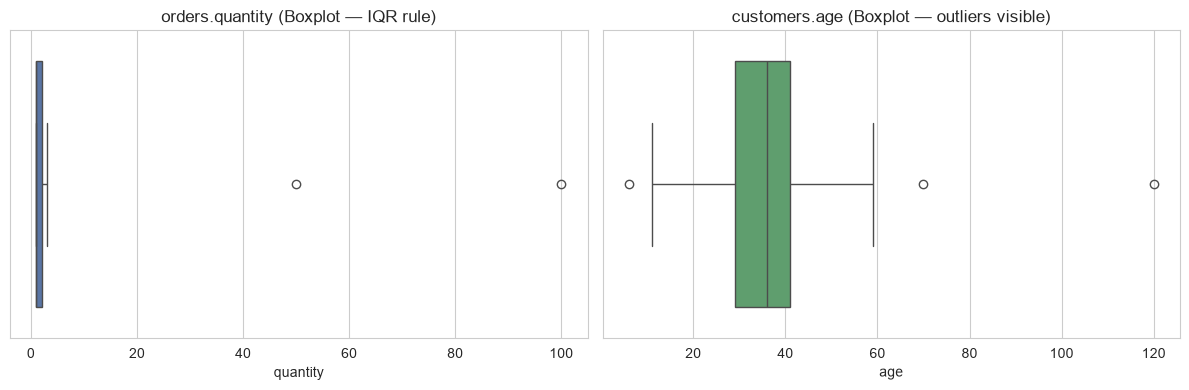

In [29]:
# 시각화로 다시 확인 — 박스플롯이 곧 IQR의 그림 표현
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=orders["quantity"], ax=axes[0], color="#4C72B0")
axes[0].set_title("orders.quantity (Boxplot — IQR rule)")
axes[0].set_xlabel("quantity")

# age는 999가 그림을 망가뜨리므로 양호 범위만 그려 비교
sns.boxplot(x=customers.loc[customers["age"].between(0, 120), "age"], ax=axes[1], color="#55A868")
axes[1].set_title("customers.age (Boxplot — outliers visible)")
axes[1].set_xlabel("age")

plt.tight_layout()
plt.show()

In [30]:
# 1) IQR 경계
mask_amt, (lo, up) = detect_outliers_iqr(orders["amount"])
print(f"하한: {lo:.0f} / 상한: {up:.0f}")

# 2) 이상치 개수·비율
n_out = mask_amt.sum()
print(f"이상치: {n_out}건 ({n_out/len(orders)*100:.2f}%)")
display(orders[mask_amt].head())


하한: -120600 / 상한: 280200
이상치: 46건 (2.30%)


,order_id,customer_id,product_id,category,quantity,amount,channel
71,O00072,C0126,P038,가전,3,389700.0,app
115,O00116,C0019,P030,가전,3,389700.0,web
133,O00134,C0003,P033,뷰티,3,389700.0,web
154,O00155,C0051,P019,도서,3,389700.0,web
195,O00196,C0009,P014,식품,3,389700.0,web


In [31]:
display(orders[mask_amt].sort_values("amount", ascending=False).head())


,order_id,customer_id,product_id,category,quantity,amount,channel
1500,O01501,C0013,P038,가전,1,5000000.0,web
71,O00072,C0126,P038,가전,3,389700.0,app
1635,O01636,C0209,P033,뷰티,3,389700.0,app
1178,O01179,C0148,P033,뷰티,3,389700.0,web
1225,O01226,C0109,P014,식품,3,389700.0,web


In [32]:
# 옵션 ① 제거 (정확히는 'NaN 표시 후 결측 처리'로 연결)
demo_a = customers.copy()

# 사람 나이로 비현실적인 값을 결측으로 표시
unrealistic = (demo_a["age"] < 0) | (demo_a["age"] > 110)
demo_a.loc[unrealistic, "age"] = np.nan

# 이제 Part 5의 결측 처리가 그대로 이어진다 — 중앙값 대체
demo_a["age"] = demo_a["age"].fillna(demo_a["age"].median())

print("처리 전 age 통계:")
print(customers["age"].describe()[["min", "max", "mean"]].round(2))
print("\n처리 후 age 통계:")
print(demo_a["age"].describe()[["min", "max", "mean"]].round(2))

처리 전 age 통계:
min      -3.00
max     999.00
mean     38.37
Name: age, dtype: float64

처리 후 age 통계:
min      6.00
max     70.00
mean    35.01
Name: age, dtype: float64


In [33]:
# 옵션 ② 클리핑(clip) — 분포의 양 끝을 경계값으로 '잘라' 영향 축소
demo_b = orders.copy()
q1 = demo_b["amount"].quantile(0.25)
q3 = demo_b["amount"].quantile(0.75)
iqr = q3 - q1
lo, up = q1 - 1.5*iqr, q3 + 1.5*iqr

# clip — 경계 밖 값을 경계값으로 대체
demo_b["amount_clipped"] = demo_b["amount"].clip(lower=lo, upper=up)

print("처리 전 amount max:", orders["amount"].max())
print("처리 후 amount_clipped max:", demo_b["amount_clipped"].max())

# 큰 5건 비교
display(
    pd.DataFrame({
        "amount": orders["amount"].nlargest(5).values,
        "amount_clipped": demo_b["amount_clipped"].nlargest(5).values,
    })
)

처리 전 amount max: 5000000.0
처리 후 amount_clipped max: 280200.0


,amount,amount_clipped
0,5000000.0,280200.0
1,389700.0,280200.0
2,389700.0,280200.0
3,389700.0,280200.0
4,389700.0,280200.0


In [34]:
# 옵션 ③ 유지 + 플래그 — 가장 안전한 기본값
demo_c = orders.copy()
mask, (lo, up) = detect_outliers_iqr(demo_c["amount"])
demo_c["amount_outlier"] = mask.astype(int)

print("이상치 플래그 분포:")
print(demo_c["amount_outlier"].value_counts())

print("\n[유지된 이상치 행]")
display(demo_c[demo_c["amount_outlier"] == 1].head())

이상치 플래그 분포:
amount_outlier
0    1954
1      46
Name: count, dtype: int64

[유지된 이상치 행]


,order_id,customer_id,product_id,category,quantity,amount,channel,amount_outlier
71,O00072,C0126,P038,가전,3,389700.0,app,1
115,O00116,C0019,P030,가전,3,389700.0,web,1
133,O00134,C0003,P033,뷰티,3,389700.0,web,1
154,O00155,C0051,P019,도서,3,389700.0,web,1
195,O00196,C0009,P014,식품,3,389700.0,web,1


In [35]:
# 우리 데이터에 결정을 적용 — 정제된 orders 만들기
orders_clean = orders.copy()

# 1) quantity 이상치 (=100, =50) → 입력 실수로 추정 (일반 소비자가 한 번에 100개 주문은 드묾)
#    → 안전하게 결측 표시 후 중앙값 대체. 진짜 대량 주문이면 customer_id로 별도 확인 가능.
mask_qty, _ = detect_outliers_iqr(orders_clean["quantity"], k=1.5)
orders_clean.loc[mask_qty, "quantity"] = np.nan
orders_clean["quantity"] = orders_clean["quantity"].fillna(orders_clean["quantity"].median()).astype(int)

# 2) amount 이상치 (=5,000,000) → 가전 카테고리의 1건 고가 거래로 보임
#    → 결정 보류: 유지 + 플래그. 평균 계산 시 필요하면 후속에서 분리.
mask_amt, _ = detect_outliers_iqr(orders_clean["amount"])
orders_clean["amount_outlier"] = mask_amt.astype(int)

# 3) amount 결측 → 채널별 중앙값 대체 (MAR 신호 — Part 4·5에서 결정)
orders_clean["amount"] = orders_clean["amount"].fillna(
    orders_clean.groupby("channel")["amount"].transform("median")
)

print("처리 결과:")
print("- quantity 결측:", orders_clean["quantity"].isnull().sum())
print("- amount 결측:", orders_clean["amount"].isnull().sum())
print("- amount_outlier=1 건수:", orders_clean["amount_outlier"].sum())

display(orders_clean.head())

처리 결과:
- quantity 결측: 0
- amount 결측: 0
- amount_outlier=1 건수: 46


,order_id,customer_id,product_id,category,quantity,amount,channel,amount_outlier
0,O00001,C0111,P004,도서,1,29900.0,app,0
1,O00002,C0014,P029,패션,3,149700.0,app,0
2,O00003,C0231,P009,식품,2,39800.0,app,0
3,O00004,C0084,P027,도서,1,29900.0,web,0
4,O00005,C0130,P026,식품,2,19800.0,app,0


In [36]:
# 새 데이터셋 — '옷장패션' 주문 (가상)
np.random.seed(11)
n = 1500

partner = pd.DataFrame({
    "order_id": [f"K{str(i).zfill(5)}" for i in range(1, n + 1)],
    "customer_age": np.random.normal(33, 8, n).round().astype(int),
    "category": np.random.choice(["상의", "하의", "신발", "액세서리"], n, p=[0.35, 0.3, 0.2, 0.15]),
    "channel": np.random.choice(["web", "app"], n, p=[0.4, 0.6]),
    "price": np.random.choice([15900, 29900, 49900, 79900, 129900], n),
    "quantity": np.random.choice([1, 1, 1, 2, 2, 3], n),
})
partner["amount"] = partner["price"] * partner["quantity"]
partner["return_amount"] = np.where(
    np.random.rand(n) < 0.07, partner["amount"] * np.random.uniform(0.5, 1.0, n), 0
).round(0)

# 오염 심기
# (a) 나이 이상치 — 입력 실수(0, 999)
partner.loc[partner.sample(3, random_state=1).index, "customer_age"] = 999
partner.loc[partner.sample(2, random_state=2).index, "customer_age"] = 0

# (b) amount 결측 — app 채널에 더 자주 (MAR 시그널)
app = partner["channel"] == "app"
partner.loc[partner[app].sample(frac=0.05, random_state=3).index, "amount"] = np.nan
partner.loc[partner[~app].sample(frac=0.01, random_state=4).index, "amount"] = np.nan

# (c) return_amount 결측은 그대로 (0=환불없음)이라 결측 아님. 단, '관찰 안 됨'을 의도적으로 표현하기 위해
#     price 결측 5건 추가(접속 시점 가격이 누락된 사례)
partner.loc[partner.sample(5, random_state=5).index, "price"] = np.nan

# (d) quantity 이상치(단일 소비자 200개)
partner.loc[partner.sample(1, random_state=6).index, "quantity"] = 200

# (e) amount 극단값(50,000,000짜리 한 건 — '도매 의심')
partner.loc[partner.sample(1, random_state=7).index, "amount"] = 50_000_000

print("옷장패션 데이터 준비 완료:", partner.shape)
partner.head()

옷장패션 데이터 준비 완료: (1500, 8)


,order_id,customer_age,category,channel,price,quantity,amount,return_amount
0,K00001,47,신발,app,29900.0,2,59800.0,45445.0
1,K00002,31,상의,app,129900.0,3,389700.0,0.0
2,K00003,29,상의,web,49900.0,2,99800.0,0.0
3,K00004,12,상의,web,49900.0,3,149700.0,0.0
4,K00005,33,하의,app,129900.0,1,129900.0,0.0


In [37]:
# 시나리오 1 — 진단
print("shape:", partner.shape)
partner.info()
display(partner.describe())

shape: (1500, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       1500 non-null   str    
 1   customer_age   1500 non-null   int64  
 2   category       1500 non-null   str    
 3   channel        1500 non-null   str    
 4   price          1495 non-null   float64
 5   quantity       1500 non-null   int64  
 6   amount         1449 non-null   float64
 7   return_amount  1500 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 93.9 KB


,customer_age,price,quantity,amount,return_amount
count,1500.000000,1495.000000,1500.000000,1.449000e+03,1500.000000
mean,34.903333,60960.869565,1.789333,1.350475e+05,6381.010000
std,43.936525,40275.103681,5.173406,1.313695e+06,28315.037316
min,0.000000,15900.000000,1.000000,1.590000e+04,0.000000
25%,28.000000,29900.000000,1.000000,4.770000e+04,0.000000
50%,33.000000,49900.000000,2.000000,7.990000e+04,0.000000
75%,38.250000,79900.000000,2.000000,1.299000e+05,0.000000
max,999.000000,129900.000000,200.000000,5.000000e+07,322778.000000


In [38]:
# IQR 이상치 — 수치형 컬럼 일괄 점검
num_cols = ["customer_age", "price", "quantity", "amount", "return_amount"]
print("[IQR 기준 이상치 개수]")
for c in num_cols:
    mask, (lo, up) = detect_outliers_iqr(partner[c].dropna())
    print(f"  {c:15s}  하한={lo:>12.1f}  상한={up:>12.1f}  이상치={mask.sum()}건")

[IQR 기준 이상치 개수]
  customer_age     하한=        12.6  상한=        53.6  이상치=18건
  price            하한=    -45100.0  상한=    154900.0  이상치=0건
  quantity         하한=        -0.5  상한=         3.5  이상치=1건
  amount           하한=    -75600.0  상한=    253200.0  이상치=145건
  return_amount    하한=         0.0  상한=         0.0  이상치=122건


In [39]:
# 시나리오 3 — 처리 코드 (예시 구현)
partner_clean = partner.copy()

# 1) customer_age 물리적 불가능 값 → NaN → 중앙값 대체
unrealistic = (partner_clean["customer_age"] < 1) | (partner_clean["customer_age"] > 110)
partner_clean.loc[unrealistic, "customer_age"] = np.nan
partner_clean["customer_age"] = partner_clean["customer_age"].fillna(
    partner_clean["customer_age"].median()
).astype(int)

# 2) quantity 이상치 → NaN → 중앙값 대체
mask_q, _ = detect_outliers_iqr(partner_clean["quantity"])
partner_clean.loc[mask_q, "quantity"] = np.nan
partner_clean["quantity"] = partner_clean["quantity"].fillna(
    partner_clean["quantity"].median()
).astype(int)

# 3) amount 이상치(50,000,000) → 유지 + 플래그
mask_a, _ = detect_outliers_iqr(partner_clean["amount"])
partner_clean["amount_outlier"] = mask_a.astype(int)

# 4) amount 결측 → 채널별 중앙값 대체 (MAR 가설)
partner_clean["amount"] = partner_clean["amount"].fillna(
    partner_clean.groupby("channel")["amount"].transform("median")
)

# 5) price 결측 → 카테고리별 중앙값 대체
partner_clean["price"] = partner_clean["price"].fillna(
    partner_clean.groupby("category")["price"].transform("median")
)

# 검증 출력
print("[처리 전 후 결측 비교]")
before = partner.isnull().sum()
after = partner_clean[partner.columns].isnull().sum()
display(pd.DataFrame({"before": before, "after": after}))

print("\n[처리 후 customer_age 범위]:",
      partner_clean["customer_age"].min(), "~", partner_clean["customer_age"].max())
print("[amount_outlier=1 건수]:", partner_clean["amount_outlier"].sum())

[처리 전 후 결측 비교]


,before,after
order_id,0,0
customer_age,0,0
category,0,0
channel,0,0
price,5,0
quantity,0,0
amount,51,0
return_amount,0,0



[처리 후 customer_age 범위]: 5 ~ 60
[amount_outlier=1 건수]: 145


In [40]:
# 코드 퀴즈 — 모범 답안
out = orders.copy()

# 1) quantity 이상치 → NaN
mask_q, _ = detect_outliers_iqr(out["quantity"])
out.loc[mask_q, "quantity"] = np.nan
# 결측 처리는 중앙값
out["quantity"] = out["quantity"].fillna(out["quantity"].median()).astype(int)

# 2) amount 결측 → 채널별 중앙값
out["amount"] = out["amount"].fillna(out.groupby("channel")["amount"].transform("median"))

# 3) 검증
print("quantity 결측:", out["quantity"].isnull().sum())
print("amount 결측:", out["amount"].isnull().sum())

quantity 결측: 0
amount 결측: 0


[열별 결측 수]
order_id          0
customer_age      0
category          0
channel           0
price             5
quantity          0
amount           51
return_amount     0
dtype: int64

[열별 결측 비율(%)]
order_id         0.00
customer_age     0.00
category         0.00
channel          0.00
price            0.33
quantity         0.00
amount           3.40
return_amount    0.00
dtype: float64

[행별 결측 개수 상위 5]
1397    1
918     1
268     1
1187    1
460     1
dtype: int64

[amount 결측 행]


,order_id,customer_age,category,channel,price,quantity,amount,return_amount
51,K00052,39,하의,app,15900.0,2,NaN,0.0
54,K00055,36,액세서리,app,129900.0,1,NaN,0.0
95,K00096,35,상의,app,15900.0,2,NaN,0.0
99,K00100,36,하의,app,29900.0,2,NaN,0.0
116,K00117,37,액세서리,app,129900.0,2,NaN,0.0



[price 결측 행]


,order_id,customer_age,category,channel,price,quantity,amount,return_amount
656,K00657,26,신발,app,NaN,3,149700.0,0.0
669,K00670,43,하의,web,NaN,1,79900.0,0.0
822,K00823,52,하의,web,NaN,1,15900.0,0.0
931,K00932,39,액세서리,web,NaN,1,129900.0,100018.0
1187,K01188,12,상의,app,NaN,2,59800.0,0.0


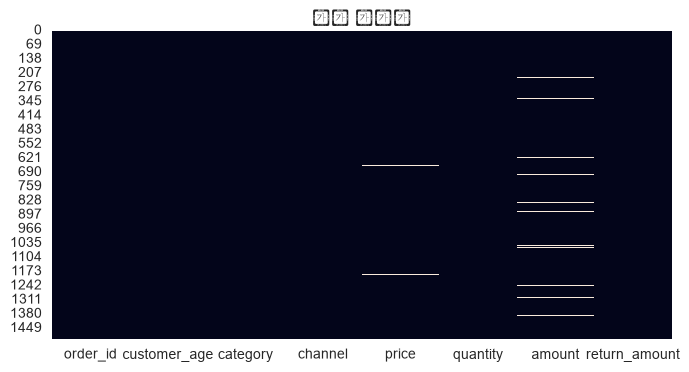

In [41]:
# 1) 결측 진단 5종 세트

# ① 열별 결측 수
print("[열별 결측 수]")
print(partner.isnull().sum())

# ② 열별 결측 비율
print("\n[열별 결측 비율(%)]")
print((partner.isnull().mean() * 100).round(2))

# ③ 행별 결측 개수
print("\n[행별 결측 개수 상위 5]")
print(partner.isnull().sum(axis=1).sort_values(ascending=False).head())

# ④ 특정 열(amount, price) 결측 행만 보기
print("\n[amount 결측 행]")
display(partner[partner["amount"].isnull()].head())

print("\n[price 결측 행]")
display(partner[partner["price"].isnull()].head())

# ⑤ 결측 히트맵
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.heatmap(partner.isnull(), cbar=False)
plt.title("결측 히트맵")
plt.show()


In [42]:
plt.rcParams['font.family'] = 'AppleGothic'  # 맥이면


## 결측·이상치 정제 보고서

### 1. 결측 유형 가설
- **amount 결측**: MAR — 결측이 `channel=app`에 몰려있음 (관측 변수에 의존)
- **price 결측**: MCAR — channel/category/age 특정 패턴 없이 무작위 분포
- (참고) return_amount는 결측이 아니라 "환불 없음=0"으로 설계된 값

### 2. 이상치 탐지
- IQR 기준 amount 상한 253,200 → 145건 이상치 (유지+플래그 처리)
- customer_age 999/0 → 입력 실수로 판단, 결측 처리 후 중앙값 대체
- quantity 200 → 이상치 1건, 결측 처리 후 중앙값 대체

### 3. 처리 결정 근거·한계
- amount 결측 → 채널별 중앙값 대체 (MAR 가정이 틀렸을 경우 편향 가능성 있음)
- price 결측 → 카테고리별 중앙값 대체
- amount 이상치(50,000,000) → 삭제하지 않고 플래그만 남김 (실제 도매 거래일 수도 있어 판단 보류)

### 4. 처리 전후 비교
- 결측: price 5→0, amount 51→0
- amount_outlier=1 건수: 145
